# Module 3 — Grad-CAM et état écologique du récif

Ce notebook complète le module de vision avec deux sorties :

1. **Grad-CAM** pour visualiser les zones ayant influencé la prédiction de MobileNetV2 ;
2. un **indice écologique expérimental par image originale**, calculé à partir des probabilités moyennes de ses patches.

## Formule de l'indice écologique

Les probabilités de la classe `Other_background` sont exclues de l'indice, car elles ne décrivent pas directement l'état du récif.

$$Risque = \frac{0.5 \times Algae + 1.0 \times Substrate\_degraded}{Live\_coral + Algae + Substrate\_degraded}$$

- `Healthy` : risque < 0,33
- `At_risk` : 0,33 ≤ risque < 0,66
- `Degraded` : risque ≥ 0,66

> Cet indice est une règle expérimentale destinée à la démonstration. Il ne remplace pas une évaluation écologique de terrain.

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver la racine du projet.")

MODEL_PATH = PROJECT_ROOT / 'models' / 'module3' / 'module3_mobilenetv2_final.keras'
PREDICTIONS_PATH = (
    PROJECT_ROOT / 'results' / 'module3' / 'mobilenetv2' / 'test_predictions.csv'
)
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module3' / 'explainability'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert MODEL_PATH.exists(), f'Modèle introuvable : {MODEL_PATH}'
assert PREDICTIONS_PATH.exists(), f'Prédictions introuvables : {PREDICTIONS_PATH}'

CLASS_NAMES = ['Live_coral', 'Algae', 'Substrate_degraded', 'Other_background']
IMG_SIZE = (224, 224)

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
predictions_df = pd.read_csv(PREDICTIONS_PATH)

print('Modèle chargé :', MODEL_PATH)
print('Prédictions chargées :', predictions_df.shape)
print('Images originales du test :', predictions_df['original_image_id'].nunique())

Modèle chargé : C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras
Prédictions chargées : (2654, 14)
Images originales du test : 280


## 1. Localisation automatique de MobileNetV2 et de sa dernière couche convolutive

In [7]:
base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and 'mobilenet' in layer.name.lower():
        base_model = layer
        break

assert base_model is not None, 'Le sous-modèle MobileNetV2 est introuvable.'

last_conv_layer = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer = layer
            break
    except Exception:
        continue

assert last_conv_layer is not None, 'Aucune couche convolutive 4D trouvée.'

last_conv_model = tf.keras.Model(
    base_model.inputs,
    [last_conv_layer.output, base_model.output]
)

base_index = model.layers.index(base_model)
head_layers = model.layers[base_index + 1:]

print('Sous-modèle :', base_model.name)
print('Dernière couche convolutive :', last_conv_layer.name)
print('Couches de classification :', [layer.name for layer in head_layers])

Sous-modèle : mobilenetv2_1.00_224
Dernière couche convolutive : out_relu
Couches de classification : ['global_average_pooling', 'dropout', 'dense_features', 'dropout_1', 'predictions']


## 2. Fonctions Grad-CAM

In [8]:
def load_image_tensor(image_path: str):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(image)
    tensor = tf.expand_dims(array, axis=0)
    return array.astype(np.uint8), tensor


def apply_classification_head(features, training=False):
    x = features
    for layer in head_layers:
        try:
            x = layer(x, training=training)
        except TypeError:
            x = layer(x)
    return x


def make_gradcam_heatmap(image_tensor, class_index=None):
    preprocessed = preprocess_input(tf.cast(image_tensor, tf.float32))

    with tf.GradientTape() as tape:
        conv_outputs, base_features = last_conv_model(preprocessed, training=False)
        tape.watch(conv_outputs)
        predictions = apply_classification_head(base_features, training=False)

        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))

        class_score = predictions[:, class_index]

    gradients = tape.gradient(class_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_gradients, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    maximum = tf.reduce_max(heatmap)
    heatmap = heatmap / (maximum + tf.keras.backend.epsilon())

    return heatmap.numpy(), predictions.numpy()[0], class_index


def overlay_heatmap(original_array, heatmap, alpha=0.40):
    original_image = Image.fromarray(original_array).convert('RGB')
    heatmap_image = Image.fromarray(np.uint8(255 * heatmap)).resize(original_image.size)
    heatmap_array = np.asarray(heatmap_image, dtype=np.float32) / 255.0

    colored_heatmap = plt.get_cmap('jet')(heatmap_array)[..., :3]
    original_float = np.asarray(original_image, dtype=np.float32) / 255.0
    overlay = np.clip((1 - alpha) * original_float + alpha * colored_heatmap, 0, 1)
    return overlay

## 3. Sélection d'exemples

Un exemple correctement classé est sélectionné pour chaque classe, puis quatre erreurs à confiance élevée sont ajoutées.

In [9]:
selected_rows = []

correct_df = predictions_df[
    predictions_df['class_id'] == predictions_df['predicted_class_id']
].copy()

for class_name in CLASS_NAMES:
    subset = correct_df[correct_df['ecological_class'] == class_name]
    if not subset.empty:
        selected_rows.append(subset.sort_values('confidence', ascending=False).iloc[0])

error_df = predictions_df[
    predictions_df['class_id'] != predictions_df['predicted_class_id']
].copy()

for _, row in error_df.sort_values('confidence', ascending=False).head(4).iterrows():
    selected_rows.append(row)

selected_df = pd.DataFrame(selected_rows).drop_duplicates(subset=['full_path']).reset_index(drop=True)
display(selected_df[[
    'name', 'ecological_class', 'predicted_class', 'confidence'
]])

,name,ecological_class,predicted_class,confidence
0,IMBRE002_5B_IMG_6208.JPG_4.png,Live_coral,Live_coral,0.999999
1,RWA003_10B_IMG_2822.JPG_8.png,Algae,Algae,0.995609
2,SLPK22_05B_IMG_1141.JPG_8.png,Substrate_degraded,Substrate_degraded,0.999987
3,SLPK02_10C_IMG_6308.JPG_10.png,Other_background,Other_background,0.998930
4,IMUAS001_05A_IMG_8706.JPG_6.png,Other_background,Live_coral,0.999996
5,RWA020_10B_IMG_3501.JPG_1.png,Algae,Live_coral,0.992597
6,IMUAS003_10B_IMG_0967.JPG_4.png,Substrate_degraded,Live_coral,0.992111
7,SLPK22_05B_IMG_1142.JPG_9.png,Substrate_degraded,Live_coral,0.981544


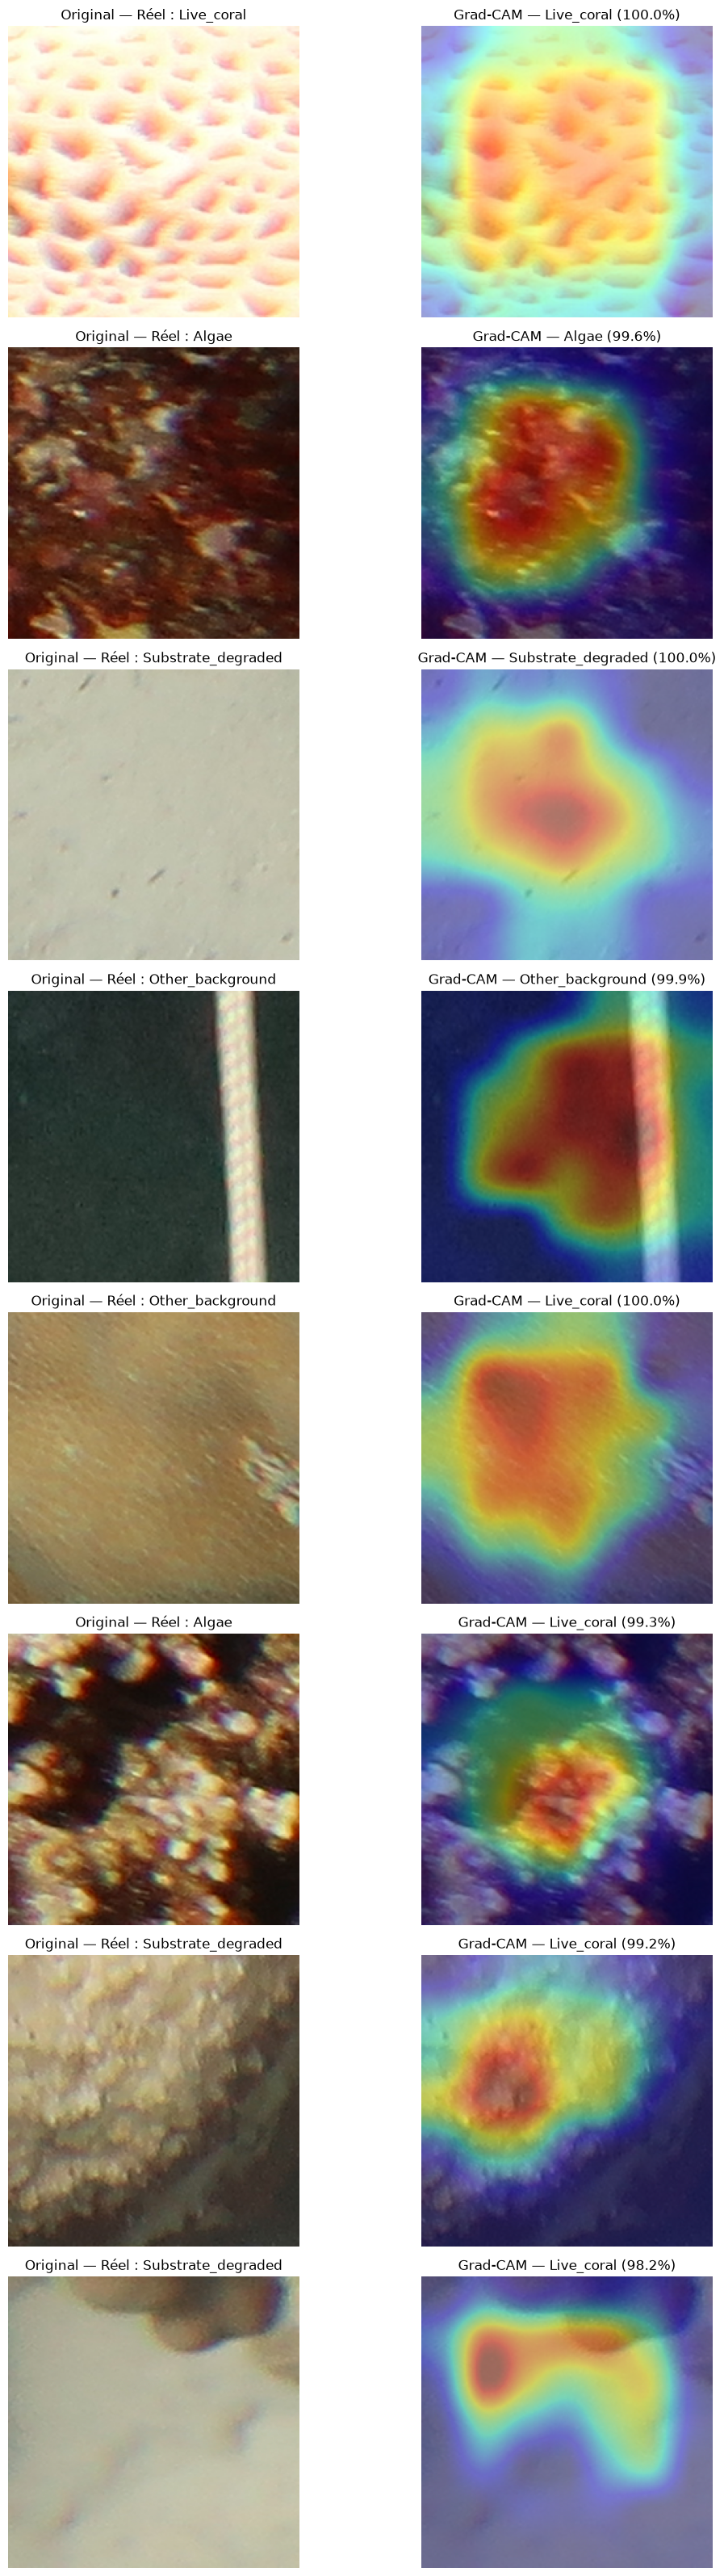

✅ Grille Grad-CAM : C:\Users\elasr\OneDrive\Desktop\hind\results\module3\explainability\gradcam_examples_grid.png


In [10]:
n_samples = len(selected_df)
plt.figure(figsize=(12, 4 * n_samples))

gradcam_records = []

for index, row in selected_df.iterrows():
    original_array, image_tensor = load_image_tensor(row['full_path'])
    heatmap, probabilities, predicted_index = make_gradcam_heatmap(image_tensor)
    overlay = overlay_heatmap(original_array, heatmap)

    predicted_name = CLASS_NAMES[predicted_index]
    confidence = float(probabilities[predicted_index])

    ax1 = plt.subplot(n_samples, 2, index * 2 + 1)
    ax1.imshow(original_array)
    ax1.set_title(f"Original — Réel : {row['ecological_class']}")
    ax1.axis('off')

    ax2 = plt.subplot(n_samples, 2, index * 2 + 2)
    ax2.imshow(overlay)
    ax2.set_title(f'Grad-CAM — {predicted_name} ({confidence:.1%})')
    ax2.axis('off')

    individual_path = RESULTS_DIR / f'gradcam_{index + 1:02d}.png'
    Image.fromarray(np.uint8(255 * overlay)).save(individual_path)

    gradcam_records.append({
        'name': row['name'],
        'true_class': row['ecological_class'],
        'predicted_class': predicted_name,
        'confidence': confidence,
        'gradcam_path': str(individual_path)
    })

plt.tight_layout()
grid_path = RESULTS_DIR / 'gradcam_examples_grid.png'
plt.savefig(grid_path, dpi=160, bbox_inches='tight')
plt.show()

pd.DataFrame(gradcam_records).to_csv(
    RESULTS_DIR / 'gradcam_examples.csv',
    index=False,
    encoding='utf-8-sig'
)

print('✅ Grille Grad-CAM :', grid_path)

## 4. Agrégation des patches par image originale

In [11]:
aggregation = predictions_df.groupby('original_image_id', as_index=False).agg(
    n_patches=('name', 'size'),
    live_probability=('prob_Live_coral', 'mean'),
    algae_probability=('prob_Algae', 'mean'),
    degraded_probability=('prob_Substrate_degraded', 'mean'),
    other_probability=('prob_Other_background', 'mean'),
    mean_confidence=('confidence', 'mean')
)

relevant_sum = (
    aggregation['live_probability']
    + aggregation['algae_probability']
    + aggregation['degraded_probability']
)

aggregation['live_relative'] = aggregation['live_probability'] / (relevant_sum + 1e-8)
aggregation['algae_relative'] = aggregation['algae_probability'] / (relevant_sum + 1e-8)
aggregation['degraded_relative'] = aggregation['degraded_probability'] / (relevant_sum + 1e-8)

aggregation['ecological_risk'] = (
    0.5 * aggregation['algae_relative']
    + 1.0 * aggregation['degraded_relative']
).clip(0, 1)

aggregation['ecological_status'] = pd.cut(
    aggregation['ecological_risk'],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=['Healthy', 'At_risk', 'Degraded'],
    right=False
).astype(str)

dominant_columns = [
    'live_probability', 'algae_probability',
    'degraded_probability', 'other_probability'
]
dominant_names = {
    'live_probability': 'Live_coral',
    'algae_probability': 'Algae',
    'degraded_probability': 'Substrate_degraded',
    'other_probability': 'Other_background'
}

aggregation['dominant_class'] = (
    aggregation[dominant_columns]
    .idxmax(axis=1)
    .map(dominant_names)
)

aggregation = aggregation.sort_values('ecological_risk', ascending=False).reset_index(drop=True)

output_path = RESULTS_DIR / 'ecological_status_by_original_image.csv'
aggregation.to_csv(output_path, index=False, encoding='utf-8-sig')

print('Nombre d’images originales :', len(aggregation))
print('\nRépartition des états écologiques :')
display(aggregation['ecological_status'].value_counts().to_frame('nombre'))

print('\nImages avec le risque le plus élevé :')
display(aggregation.head(15))

print('✅ Résultats écologiques :', output_path)

Nombre d’images originales : 280

Répartition des états écologiques :


,nombre
ecological_status,
At_risk,170
Degraded,65
Healthy,45



Images avec le risque le plus élevé :


,original_image_id,n_patches,live_probability,algae_probability,degraded_probability,other_probability,mean_confidence,live_relative,algae_relative,degraded_relative,ecological_risk,ecological_status,dominant_class
0,HAR326_22A_IMG_3835 (19).JPG,10,0.005637,0.013172,0.887807,0.093385,0.969598,0.006218,0.014528,0.979254,0.986518,Degraded,Substrate_degraded
1,TydemaniaforTrainingHAR326IMG_3835 (11).JPG,10,0.017514,0.037221,0.726305,0.218960,0.911800,0.022424,0.047656,0.929920,0.953748,Degraded,Substrate_degraded
2,IMSHE002_10A_IMG_2040.JPG,10,0.021441,0.054566,0.907722,0.016270,0.907722,0.021796,0.055469,0.922736,0.950470,Degraded,Substrate_degraded
3,HAR330_20A_IMG_3247 (5).JPG,10,0.012985,0.068741,0.870392,0.047881,0.918264,0.013638,0.072198,0.914164,0.950263,Degraded,Substrate_degraded
4,Tydemaniafortraining_IMG_3285 (13).JPG,10,0.009733,0.075758,0.770582,0.143927,0.871594,0.011370,0.088494,0.900136,0.944383,Degraded,Substrate_degraded
5,HAR330_20A_IMG_3247 (13).JPG,10,0.026828,0.062411,0.856143,0.054618,0.857835,0.028378,0.066016,0.905605,0.938613,Degraded,Substrate_degraded
6,HAR326_22A_IMG_3835 (20).JPG,10,0.009984,0.108910,0.844431,0.036675,0.867955,0.010364,0.113056,0.876580,0.933108,Degraded,Substrate_degraded
7,HAR319_22A_IMG_3286 (10).JPG,10,0.016485,0.163309,0.810732,0.009475,0.810732,0.016643,0.164871,0.818487,0.900922,Degraded,Substrate_degraded
8,HAR326_22A_IMG_3835 (10).JPG,10,0.035904,0.108694,0.742632,0.112769,0.850947,0.040468,0.122510,0.837022,0.898277,Degraded,Substrate_degraded
9,IMSHE003_10A_IMG_1445.JPG,8,0.063860,0.060296,0.755672,0.120172,0.833751,0.072582,0.068532,0.858886,0.893152,Degraded,Substrate_degraded


✅ Résultats écologiques : C:\Users\elasr\OneDrive\Desktop\hind\results\module3\explainability\ecological_status_by_original_image.csv


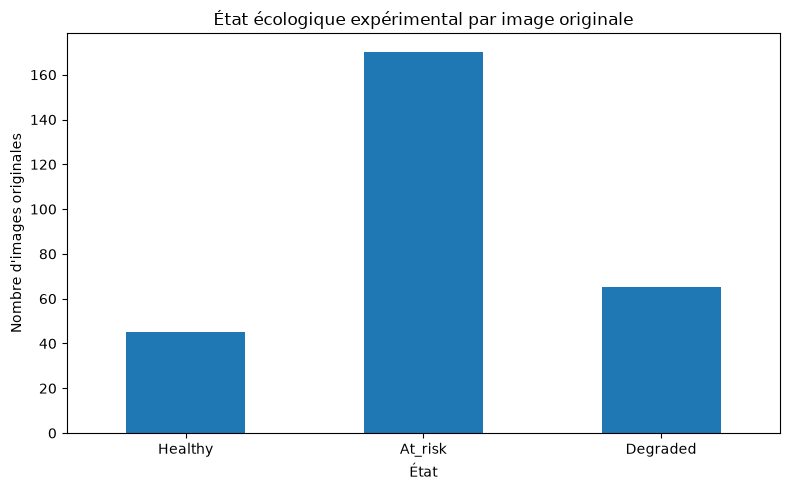

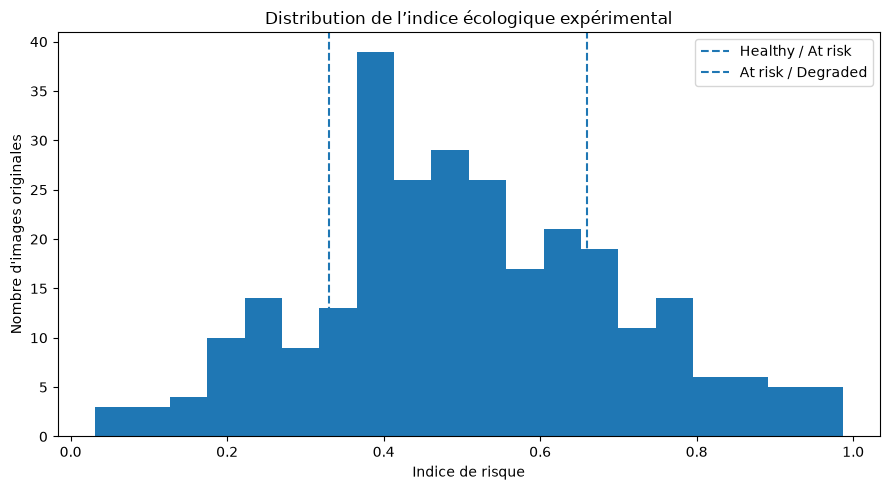

In [12]:
status_order = ['Healthy', 'At_risk', 'Degraded']
status_counts = aggregation['ecological_status'].value_counts().reindex(status_order, fill_value=0)

plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar')
plt.title('État écologique expérimental par image originale')
plt.xlabel('État')
plt.ylabel("Nombre d'images originales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'ecological_status_distribution.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(aggregation['ecological_risk'], bins=20)
plt.axvline(0.33, linestyle='--', label='Healthy / At risk')
plt.axvline(0.66, linestyle='--', label='At risk / Degraded')
plt.title('Distribution de l’indice écologique expérimental')
plt.xlabel('Indice de risque')
plt.ylabel("Nombre d'images originales")
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'ecological_risk_histogram.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

## 5. Sauvegarde de la méthodologie

In [13]:
methodology = {
    'gradcam_last_convolution_layer': last_conv_layer.name,
    'ecological_index': (
        '(0.5 * relative_algae_probability + '
        '1.0 * relative_degraded_probability)'
    ),
    'relative_probabilities_exclude': 'Other_background',
    'thresholds': {
        'Healthy': '[0.00, 0.33)',
        'At_risk': '[0.33, 0.66)',
        'Degraded': '[0.66, 1.00]'
    },
    'warning': (
        'This is an experimental rule-based ecological index. '
        'It is not a field-validated ecological diagnosis.'
    )
}

methodology_path = RESULTS_DIR / 'ecological_methodology.json'
methodology_path.write_text(
    json.dumps(methodology, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print('✅ Méthodologie sauvegardée :', methodology_path)

✅ Méthodologie sauvegardée : C:\Users\elasr\OneDrive\Desktop\hind\results\module3\explainability\ecological_methodology.json


## Fichiers attendus

Dans `results/module3/explainability/` :

- `gradcam_examples_grid.png`
- plusieurs images `gradcam_XX.png`
- `gradcam_examples.csv`
- `ecological_status_by_original_image.csv`
- `ecological_status_distribution.png`
- `ecological_risk_histogram.png`
- `ecological_methodology.json`

Le module 3 sera alors complet.